In [2]:
print('debug')

debug


In [3]:
import gc
import json
import sys
import warnings
import os 
from pathlib import Path
from typing import Dict, Generator, List, Tuple
import numpy as np
import pandas as pd
import pyarrow as pa
import lightgbm as lgb
from pandas.api.types import CategoricalDtype
from pandas.api.types import CategoricalDtype
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score
from scipy.stats import poisson, spearmanr
import warnings
import gc
import json
from ngboost import NGBRegressor
from ngboost.distns import Poisson as NGBPoisson
from ngboost.scores import LogScore, CRPScore
from lightgbmlss.model import LightGBMLSS
from lightgbmlss.distributions.Poisson import Poisson as LGBMLSSPoisson
from lightgbmlss.distributions.NegativeBinomial import NegativeBinomial
from typing import List, Union, Optional
from sklearn.base import BaseEstimator
from scipy.stats import nbinom, poisson

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ============================================================
# Configuration
# ============================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# ============================================================
# Project paths
# ============================================================
NOTEBOOK = "cards"
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "configs" / f"{NOTEBOOK}"
# ============================================================
# Project modules
# ============================================================
from src.config.config import load_target_config

from src.utils.utils import (
      split_data,
      clean_key_missing,
      prepare_data_for_training,
      align_frame_to_reference,
      assert_same_categorical_schema,
      categorical_columns,
  )

from src.preprocessing.preprocessing import (
    corregir_marcadores_90,
    clean_dataset,
)

# Pipeline de distribucion
  # =============================================================================
from src.config.config import load_target_config

from src.metrics.distribution_metrics import (
    calculate_rps,
    calculate_nll,
    calculate_ece_by_threshold,
    evaluate_distribution_model,
    evaluate_from_config,
    total_pmf,
)

from src.training.distribution_models import (
    MODEL_NAMES,
    train_and_predict,
    predict_params,
    clip_params,
)

from src.training.distribution_cv import (
    build_component_data,
    compare_models,
    evaluate_on_validation,
    likelihood_ratio_test,
)

from src.hypertunning.distribution_tuning import run_tuning, tune_and_save

from src.evaluation.persistence import (
    save_evaluation,
    save_metrics,
    save_best_params,
    load_best_params,
)

from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer

from src.utils.utils import save_feature_datasets
# ============================================================
# Experiment configuration
# ============================================================
TRAIN_MODE = True

COMP_TYPE = "clubs"

DATA_PATH = DATA_DIR / COMP_TYPE
RANDOM_STATE = 67
FEATURE_SELECTION_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset"
METRICS_DIR = OUTPUTS_DIR / COMP_TYPE / "model_metrics"
MODELS_DIR = OUTPUTS_DIR / COMP_TYPE / "models" / f"{NOTEBOOK}" 
SUBSET_DIR = OUTPUTS_DIR / COMP_TYPE / "feature_selection_subset" / f"{NOTEBOOK}"

SPLITS = {
    "train": ["2021/2022", "2022/2023", "2023/2024"],
    "val": ["2024/2025"],
    "test": ["2025/2026"],
}

# ============================================================
# Load data
# ============================================================
gc.collect()
df_cleaned = pd.read_parquet(DATA_PATH / "club_features_dataset.parquet")



c:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
exclude_list = ["match_datetime_utc", "name", "match_id", "tournament"]

EXCLUDE_COLS, LEAKY_COLS, TARGET_COL = clean_dataset(df_cleaned, ["home_total_cards", "away_total_cards"])

df_ready = clean_key_missing(df_cleaned, cols_to_check = ["home_score", "away_score", "home_total_cards", "away_total_cards"])

df_train, df_val, df_test = split_data(
    df_ready,
    SPLITS
)

print(f"The shape of the TRAIN DATA IS: {df_train.shape}")
print(f"The shape of the VAL DATA IS: {df_val.shape}")
print(f"The shape of the TEST DATA IS: {df_test.shape}")


X_train, y_train, category_map = prepare_data_for_training(
    df_train,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
)

X_val, y_val, _ = prepare_data_for_training(
    df_val,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

X_test, y_test, _ = prepare_data_for_training(
    df_test,
    EXCLUDE_COLS,
    LEAKY_COLS,
    TARGET_COL,
    category_map=category_map,
)

print(f"The TRAIN SHAPE IS: {X_train.shape} & {y_train.shape}")
print(f"The VAL SHAPE IS: {X_val.shape} & {y_val.shape}")
print(f"The TEST SHAPE IS: {X_test.shape} & {y_test.shape}")


Removed 578 rows with missing key odds.
Remaining rows: 11829
The shape of the TRAIN DATA IS: (7054, 1416)
The shape of the VAL DATA IS: (2248, 1416)
The shape of the TEST DATA IS: (2527, 1416)
The TRAIN SHAPE IS: (7054, 1048) & (7054, 2)
The VAL SHAPE IS: (2248, 1048) & (2248, 2)
The TEST SHAPE IS: (2527, 1048) & (2527, 2)


In [5]:
print(f'Mean home: {y_train["home_total_cards"].mean()} & variance {y_train["home_total_cards"].var()}')
print(f'Mean away: {y_train["away_total_cards"].mean()} & variance {y_train["away_total_cards"].var()}')
zero_home_ratio = (y_train["home_total_cards"] == 0).sum()
zero_away_ratio = (y_train["away_total_cards"] == 0).sum()
print(f'El tamaño de la muestra es de: {X_train.shape[0]}')
print(f'The zero ratio on home is: {zero_home_ratio/y_train.shape[0]:.4f} & The zero ratio Away is: {zero_away_ratio/y_train.shape[0]:.4f}')


Mean home: 1.9676779132407145 & variance 1.9666284650813675
Mean away: 2.2493620640771192 & variance 2.1327622471697643
El tamaño de la muestra es de: 7054
The zero ratio on home is: 0.1406 & The zero ratio Away is: 0.0988


In [6]:
from src.training.distribution_models import train_model
cfg = load_target_config("cards")

model_home = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train["home_total_cards"], X_val, y_val["home_total_cards"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

In [7]:
print("Training Away Cards Model...")
model_away = train_model(
    "LightGBMLSS", "poisson",
    X_train, y_train["away_total_cards"], X_val, y_val["away_total_cards"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
)

Training Away Cards Model...


### Baseline

In [8]:
from src.training.distribution_models import train_and_predict

model_home, params_home = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["home_total_cards"],
    X_val,   y_val["home_total_cards"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

model_away, params_away = train_and_predict(
    "LightGBMLSS", "poisson",
    X_train, y_train["away_total_cards"],
    X_val,   y_val["away_total_cards"],
    params=cfg.model_params("LightGBMLSS"),
    fit_params=cfg.fit_params("LightGBMLSS"),
    guards=cfg.numeric_guards,
)

from src.metrics.distribution_metrics import evaluate_from_config
from src.evaluation.persistence import save_evaluation

results = evaluate_from_config(
    y_true={
        "home": y_val["home_total_cards"].values,
        "away": y_val["away_total_cards"].values,
    },
    params={"home": params_home, "away": params_away},
    config=cfg,
    family="poisson",
    label="Baseline Poisson (LightGBMLSS)",
    verbose=True,
)

save_evaluation(
      results,
      name="baseline_poisson_validation_results",
      config=cfg,
      metadata={
          "models": {"home": "LightGBMLSS", "away": "LightGBMLSS"},
          "split": "validation",
          "n_features": {"home": X_train.shape[1],
                         "away": X_train.shape[1]},
      },
  )


  FULL EVALUATION - Baseline Poisson (LightGBMLSS) [poisson]

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.71166   <- principal
  RPS std         : 0.57140
  RPS median      : 0.51678
  RPS p95         : 1.86479   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - Baseline Poisson (LightGBMLSS) | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.76988   <- principal
  RPS std         : 0.62390
  RPS median      : 0.54632
  RPS p95         : 1.97269   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - Baseline Poisson (LightGBMLSS) | home [poisson]
--------------------------------------------------
  N observacio

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/cards/baseline_poisson_validation_results.json')

### Feature selection Process

In [9]:
from src.config.config import load_config
from src.feature_selection.poisson_feature_selection import (
    PoissonSelectionConfig, run_poisson_feature_selection,
)

cfg = load_config(CONFIG_PATH / "cards_config.yaml")
sel_cfg = PoissonSelectionConfig.from_model_config(cfg)   # todo del YAML

home_final_features, Xtr_home, Xvl_home, Xte_home, report_home = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["home_total_cards"],
    y_val=y_val["home_total_cards"],
    target_name="home_total_cards",
    cfg=sel_cfg,
    max_k=cfg.target.max_k,
)


  [CHECK] El indice no es DatetimeIndex; no se puede verificar el
          orden cronologico automaticamente. Confirma a mano que
          X_train esta ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = home_total_cards
  Train: (7054, 1048)   Val: (2248, 1048)   Test: (2527, 1048)
  Target: media = 1.9677, var = 1.9663, var/media = 0.999
  Ratio filas/features: 6.7:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categoricas declaradas: 57
  Esquema train/val/test: alineado y verificado.

  [AUDIT] 3 categoricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004               0.0305
home_roll_5_sp_goals_against              18              0.0009               0.0301
away_roll_5_sp_goals_against              1

### Feature Selection Process END

In [10]:
home_final_features

['h2h_avg_total_yellows_last_5',
 'away_opponent_avg_yellows_last_20',
 'home_total_shots_elo_prob',
 'diff_roll_5_team_squad_value_eur',
 'tournament',
 'home_team_avg_yellows_last_20',
 'home_team_avg_fouls_padj_last_20',
 'diff_team_avg_foul_opp_final_third_last_20']

In [11]:
print(f"Inicio               : {report_home.n_start}")
print(f"Post Sparsity (S0)   : {report_home.n_after_sparsity}")
print(f"Post MI (S1)         : {report_home.n_after_mi}")        
print(f"Post Correlación (S2): {report_home.n_after_corr}")      
print(f"Post Permutación (S3): {report_home.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_home.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 172
Post Correlación (S2): 104
Post Permutación (S3): 9
Post Estabilidad (S4): 8


In [12]:
away_final_features, Xtr_away, Xvl_away, Xte_away, report_away = run_poisson_feature_selection(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train["away_total_cards"],
    y_val=y_val["away_total_cards"],
    target_name="away_total_cards",
    cfg=sel_cfg,
    max_k=cfg.target.max_k,
)

  [CHECK] El indice no es DatetimeIndex; no se puede verificar el
          orden cronologico automaticamente. Confirma a mano que
          X_train esta ordenado por fecha ASCENDENTE.
  POISSON TEMPORAL FEATURE SELECTION — target = away_total_cards
  Train: (7054, 1048)   Val: (2248, 1048)   Test: (2527, 1048)
  Target: media = 2.2494, var = 2.1325, var/media = 0.948
  Ratio filas/features: 6.7:1
  Semilla: 67   Workers: 8

  STEP 0 — Sparsity Filter  (moda > 95%, NaN > 95%)
  Features entrada    : 1048
  Cuasi-constantes    : 37
  Features restantes  : 1011

  Categoricas declaradas: 57
  Esquema train/val/test: alineado y verificado.

  [AUDIT] 3 categoricas con niveles no vistos (>1%):
                     feature  n_levels_train  val_extra_nan_rate  test_extra_nan_rate
    home_roll_5_sp_goals_for              17              0.0004               0.0305
home_roll_5_sp_goals_against              18              0.0009               0.0301
away_roll_5_sp_goals_against              1

In [13]:
away_final_features

['h2h_avg_total_yellows_last_5',
 'home_opponent_avg_yellows_last_20',
 'diff_pct_team_scores_first_goal_last_20',
 'tournament',
 'home_total_shots_elo_prob',
 'away_team_avg_fouls_committed_last_20',
 'ref_avg_yellows_last_10',
 'away_team_avg_yellows_last_10',
 'h2h_home_avg_yellows_last_5']

In [14]:
print(f"Inicio               : {report_away.n_start}")
print(f"Post Sparsity (S0)   : {report_away.n_after_sparsity}")
print(f"Post MI (S1)         : {report_away.n_after_mi}")        
print(f"Post Correlación (S2): {report_away.n_after_corr}")      
print(f"Post Permutación (S3): {report_away.n_after_shuffle}")   
print(f"Post Estabilidad (S4): {report_away.n_after_stability}")

Inicio               : 1048
Post Sparsity (S0)   : 1011
Post MI (S1)         : 121
Post Correlación (S2): 80
Post Permutación (S3): 9
Post Estabilidad (S4): 9


In [15]:
print(f"\nFeatures HOME: {len(home_final_features)} & {home_final_features}")
print(f"Features AWAY: {len(away_final_features)} & {away_final_features}")


Features HOME: 8 & ['h2h_avg_total_yellows_last_5', 'away_opponent_avg_yellows_last_20', 'home_total_shots_elo_prob', 'diff_roll_5_team_squad_value_eur', 'tournament', 'home_team_avg_yellows_last_20', 'home_team_avg_fouls_padj_last_20', 'diff_team_avg_foul_opp_final_third_last_20']
Features AWAY: 9 & ['h2h_avg_total_yellows_last_5', 'home_opponent_avg_yellows_last_20', 'diff_pct_team_scores_first_goal_last_20', 'tournament', 'home_total_shots_elo_prob', 'away_team_avg_fouls_committed_last_20', 'ref_avg_yellows_last_10', 'away_team_avg_yellows_last_10', 'h2h_home_avg_yellows_last_5']


In [16]:
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("cards")

X_tr = {"home": X_train, "away": X_train}
y_tr = {"home": y_train["home_total_cards"], "away": y_train["away_total_cards"]}
X_va = {"home": X_val,   "away": X_val}
y_va = {"home": y_val["home_total_cards"],   "away": y_val["away_total_cards"]}
feats = {"home": home_final_features, "away": away_final_features}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models=["LightGBMLSS"],
    family="poisson",
    verbose=True,
)

save_evaluation(
    results["LightGBMLSS"],
    "feature_selected_validation_baseline_results_cards",
    cfg,
    metadata={"split": "2024/2025", "label": "LightGBMLSS Baseline"},
)

--- Entrenando LightGBMLSS | home [poisson] ---
--- Entrenando LightGBMLSS | away [poisson] ---

  FULL EVALUATION - LightGBMLSS | poisson [poisson]

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.71282   <- principal
  RPS std         : 0.55358
  RPS median      : 0.51436
  RPS p95         : 1.78219   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - LightGBMLSS | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.76898   <- principal
  RPS std         : 0.59836
  RPS median      : 0.55336
  RPS p95         : 1.90288   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - LightGBMLSS | poisson | home [poisson]
-----

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/cards/feature_selected_validation_baseline_results_cards.json')

In [17]:
import pandas as pd
from pathlib import Path
from typing import List

# Define the Metadata columns you want to keep
METADATA_COLS = [
    "match_datetime_utc",
    "match_id",
    "name",
    "home_total_cards",
    "away_total_cards",
]

def prepare_and_save_datasets(
    df: pd.DataFrame,
    home_features: List[str],
    away_features: List[str],
    output_path: Path,
    home_name: str = "home_total_cards_feature_selection.parquet",
    away_name: str = "away_total_cards_feature_selection.parquet"
):
    print("--- Saving Final Datasets ---")

    df = df.copy()

    # Move the SAFETY FIX here to ensure RECENT_FORM_CHECK_IN receives a DataFrame with unique columns
    # 1. SAFETY FIX: Remove any duplicate columns that might have been created
    df = df.loc[:, ~df.columns.duplicated()].copy()


    # The line below was moved up to before RECENT_FORM_CHECK_IN
    # df = df.loc[:, ~df.columns.duplicated()].copy()

    # 2. Ensure Datetime format
    if not pd.api.types.is_datetime64_any_dtype(df["match_datetime_utc"]):
        df["match_datetime_utc"] = pd.to_datetime(df["match_datetime_utc"], format="ISO8601", errors="coerce")

    # NOTE: We removed the redundant feature engineering steps here
    # because your `df` already contains all the engineered features!

    print(f"Data Shape before saving: {df.shape}")

    # ==============================================================================
    # 3. SAVE HOME DATASET
    # ==============================================================================
    cols_to_save_home = METADATA_COLS + home_features
    cols_to_save_home = list(dict.fromkeys(cols_to_save_home)) # Remove duplicates

    valid_cols_home = [c for c in cols_to_save_home if c in df.columns]

    missing_home = set(cols_to_save_home) - set(valid_cols_home)
    if missing_home:
        print(f"\n[Home] Note: The following missing features were excluded from parquet: {missing_home}")

    df[valid_cols_home].to_parquet(output_path / home_name, index=False)
    print(f"Saved {home_name} with {len(valid_cols_home)} columns.")

    # ==============================================================================
    # 4. SAVE AWAY DATASET
    # ==============================================================================
    cols_to_save_away = METADATA_COLS + away_features
    cols_to_save_away = list(dict.fromkeys(cols_to_save_away))

    valid_cols_away = [c for c in cols_to_save_away if c in df.columns]

    missing_away = set(cols_to_save_away) - set(valid_cols_away)
    if missing_away:
        print(f"\n[Away] Note: The following missing features were excluded from parquet: {missing_away}")

    df[valid_cols_away].to_parquet(output_path / away_name, index=False)
    print(f"Saved {away_name} with {len(valid_cols_away)} columns.")

# Execute the save function
prepare_and_save_datasets(
    df=df_ready,
    home_features=home_final_features,
    away_features=away_final_features,
    output_path=SUBSET_DIR,
    home_name="home_total_cards_feature_selection.parquet",
    away_name="away_total_cards_feature_selection.parquet"
)

--- Saving Final Datasets ---
Data Shape before saving: (11829, 1416)
Saved home_total_cards_feature_selection.parquet with 13 columns.
Saved away_total_cards_feature_selection.parquet with 14 columns.


### Model Creation

In [18]:
TARGET_COLS = ["home_total_cards", "away_total_cards"]

EXCLUDE_COLS = [
    'match_datetime_utc',
    'match_id',
    'name'
]

LEAKY_COLS = ["home_total_cards", "away_total_cards"]

df_home = pd.read_parquet(SUBSET_DIR / 'home_total_cards_feature_selection.parquet')
df_away = pd.read_parquet(SUBSET_DIR / 'away_total_cards_feature_selection.parquet')

df_train_home, df_val_home, df_test_home = split_data(df_home, SPLITS)
df_train_away, df_val_away, df_test_away = split_data(df_away, SPLITS)

X_train_home, y_train_home, cat_features_home = prepare_data_for_training(df = df_train_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_home, y_val_home, _ = prepare_data_for_training(df = df_val_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
X_test_home, y_test_home, _ = prepare_data_for_training(df = df_test_home, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_home)
print('HOME INFO')
print(f'The TRAIN SHAPE IS: {X_train_home.shape} & {y_train_home.shape}')
print(f'The VAL SHAPE IS: {X_val_home.shape} & {y_val_home.shape}')
print(f'The TEST SHAPE IS: {X_test_home.shape} & {y_test_home.shape}')

print('AWAY INFO')
X_train_away, y_train_away, cat_features_away = prepare_data_for_training(df = df_train_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=None)
X_val_away, y_val_away, _ = prepare_data_for_training(df = df_val_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
X_test_away, y_test_away, _ = prepare_data_for_training(df = df_test_away, EXCLUDE_COLS=EXCLUDE_COLS, leaky_cols = None, TARGET_COL=TARGET_COLS, category_map=cat_features_away)
print(f'The TRAIN SHAPE IS: {X_train_away.shape} & {y_train_away.shape}')
print(f'The VAL SHAPE IS: {X_val_away.shape} & {y_val_away.shape}')
print(f'The TEST SHAPE IS: {X_test_away.shape} & {y_test_away.shape}')

HOME INFO
The TRAIN SHAPE IS: (7054, 8) & (7054, 2)
The VAL SHAPE IS: (2248, 8) & (2248, 2)
The TEST SHAPE IS: (2527, 8) & (2527, 2)
AWAY INFO
The TRAIN SHAPE IS: (7054, 9) & (7054, 2)
The VAL SHAPE IS: (2248, 9) & (2248, 2)
The TEST SHAPE IS: (2527, 9) & (2527, 2)


In [19]:
from src.config.config import load_target_config
from src.training.distribution_cv import compare_models
from src.evaluation.persistence import save_metrics

cfg = load_target_config("cards")

X     = {"home": X_train_home, "away": X_train_away}
y     = {"home": y_train_home["home_total_cards"], "away": y_train_away["away_total_cards"]}
feats = {"home": X_train_home.columns.tolist(), "away": X_train_away.columns.tolist()}

comparison = compare_models(cfg, X, y, feats)   # 3 modelos x 2 familias x 2 componentes

print(comparison["summary"].to_string(index=False))
print(comparison["lr_tests"].to_string(index=False))

save_metrics(
    {
        "summary":   comparison["summary"],
        "lr_tests":  comparison["lr_tests"],
        "failures":  comparison["failures"],
    },
    "model_selection_results_validation",
    cfg,
)


  [LightGBMLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 0.73897 | NLL: 1.65747
    Fold 2 - RPS: 0.76595 | NLL: 1.69557
    Fold 3 - RPS: 0.73325 | NLL: 1.65284
    Fold 4 - RPS: 0.74695 | NLL: 1.67608
    Fold 5 - RPS: 0.71300 | NLL: 1.63959

  [LightGBMLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 2.21608 | NLL: 2.57572
    Fold 2 - RPS: 2.40358 | NLL: 2.70008
    Fold 3 - RPS: 1.24070 | NLL: 2.03169
    Fold 4 - RPS: 1.33163 | NLL: 2.10079
    Fold 5 - RPS: 2.78796 | NLL: 2.91254

  [XGBoostLSS | poisson] TSCV (n_splits=5)...
    Fold 1 - RPS: 0.74050 | NLL: 1.65991
    Fold 2 - RPS: 0.76839 | NLL: 1.69941
    Fold 3 - RPS: 0.72887 | NLL: 1.64886
    Fold 4 - RPS: 0.75358 | NLL: 1.68698
    Fold 5 - RPS: 0.71298 | NLL: 1.63924

  [XGBoostLSS | negbin] TSCV (n_splits=5)...
    Fold 1 - RPS: 1.83292 | NLL: 2.35766
    Fold 2 - RPS: 0.94310 | NLL: 1.90228
    Fold 3 - RPS: 2.70247 | NLL: 2.86027
    Fold 4 - RPS: 1.23515 | NLL: 2.09326
    Fold 5 - RPS: 1.97309 | NLL: 

WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/cards/model_selection_results_validation.json')

In [23]:
runs = {}

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_total_cards"], "away": y_train_away["away_total_cards"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_total_cards"],   "away": y_val_away["away_total_cards"]}
feats = {"home": X_train_home.columns.to_list(), "away": X_train_away.columns.to_list()}

for fam in cfg.distributions:          # ["poisson", "negbin"]
    summary, results = evaluate_on_validation(
        cfg, X_tr, y_tr, X_va, y_va, feats,
        family=fam,
        verbose=False,
    )
    runs[fam] = summary.assign(family=fam)

save_metrics(pd.concat(runs.values(), ignore_index=True),
            "validation_results_by_model_cards", cfg)

 [METRICS] validation_results_by_model_cards -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\cards\validation_results_by_model_cards.json


WindowsPath('C:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/clubs/model_metrics/cards/validation_results_by_model_cards.json')

### Hypertunning

In [21]:
from src.config.config import load_target_config
from src.hypertunning.distribution_tuning import tune_and_save

cfg = load_target_config("cards")

tuning_poisson_home_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_home,
    y_train       = y_train_home["home_total_cards"],
    features      = X_train_home.columns.to_list(),
    config        = cfg,
    component_key = "home",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | home
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 8


Best trial: 71. Best value: 1.65908: 100%|██████████| 100/100 [44:35<00:00, 26.76s/it]


  Best nll      : 1.65908
  Completed trials : 98
  Pruned trials    : 2
  Best params:
    max_depth             : 2
    min_samples_leaf      : 49
    n_estimators          : 1950
    learning_rate         : 0.005003882139056356
    col_sample            : 0.7451044774412743
 [CONFIG] best_params_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\cards\best_params_ngboost_poisson_home.yaml
 [METRICS] tuning_ngboost_poisson_home -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\cards\tuning_ngboost_poisson_home.json


In [22]:
cfg = load_target_config("cards")

tuning_poisson_away_ng = tune_and_save(
    model_name    = "NGBoost",
    family        = "poisson",              # o "negbin", segun el LR test
    X_train       = X_train_away,
    y_train       = y_train_away["away_total_cards"],
    features      = X_train_away.columns.to_list(),
    config        = cfg,
    component_key = "away",
    n_trials      = 100,
    n_splits      = 5,
)


  OPTUNA TUNING - NGBoost | poisson | away
  Metrica objetivo : nll (menor es mejor)
  Trials : 100 | TSCV folds : 5
  Features : 9


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 82. Best value: 1.71823: 100%|██████████| 100/100 [44:04<00:00, 26.44s/it]


  Best nll      : 1.71823
  Completed trials : 83
  Pruned trials    : 17
  Best params:
    max_depth             : 2
    min_samples_leaf      : 11
    n_estimators          : 1300
    learning_rate         : 0.005552618533578472
    col_sample            : 0.7260144888091878
 [CONFIG] best_params_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\configs\cards\best_params_ngboost_poisson_away.yaml
 [METRICS] tuning_ngboost_poisson_away -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\cards\tuning_ngboost_poisson_away.json


In [24]:
from pathlib import Path
from src.config.config import load_target_config
from src.training.distribution_cv import evaluate_on_validation
from src.evaluation.persistence import save_evaluation

cfg = load_target_config("cards")

X_tr  = {"home": X_train_home, "away": X_train_away}
y_tr  = {"home": y_train_home["home_total_cards"], "away": y_train_away["away_total_cards"]}
X_va  = {"home": X_val_home,   "away": X_val_away}
y_va  = {"home": y_val_home["home_total_cards"],   "away": y_val_away["away_total_cards"]}
feats = {"home": X_train_home.columns.to_list(), "away": X_train_away.columns.to_list()}

# Cada componente con los hiperparametros que gano SU tuning
best = {"NGBoost": {
    "home": tuning_poisson_home_ng["best_params"],
    "away": tuning_poisson_away_ng["best_params"],
}}

summary, results = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,
    models      = ["NGBoost"],
    family      = "poisson",
    best_params = best,
)

print(summary.to_string(index=False))

MODEL_DIR = OUTPUTS_DIR / "models" / "cards"

save_evaluation(
    results["NGBoost"],
    "hypertunned_ngboost_validation_results",
    cfg,
    metadata    = {"label": "NGBoost_Tuned_Poisson", "stage": "feature_selection_subset"},
    metrics_dir = MODEL_DIR,
)

--- Entrenando NGBoost | home [poisson] ---
--- Entrenando NGBoost | away [poisson] ---

  FULL EVALUATION - NGBoost | poisson [poisson]

--------------------------------------------------
  RPS Report - NGBoost | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.71149   <- principal
  RPS std         : 0.53762
  RPS median      : 0.51886
  RPS p95         : 1.76045   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2248
  RPS mean        : 0.77192   <- principal
  RPS std         : 0.58564
  RPS median      : 0.56161
  RPS p95         : 1.87026   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | poisson | home [poisson]
-----------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/models/cards/hypertunned_ngboost_validation_results.json')

### Error Analysis


  NGBoost_poisson_Tuned [poisson] - HOME | N=2,248
  RPS mean=0.71149  |  media predicha=1.8927

------------------------------------------------------------
  [1] Calibracion - NGBoost_poisson_Tuned | HOME
------------------------------------------------------------
  pred_bin   n  pred_mean  ytrue_mean  rps_mean
[0.5, 1.0)  49   0.885533    1.204082  0.617924
[1.0, 1.5) 326   1.309391    1.349693  0.647777
[1.5, 2.0) 974   1.785007    1.723819  0.657161
[2.0, 2.5) 754   2.194158    2.194960  0.768717
[2.5, 3.0) 133   2.657947    2.729323  0.948043
[3.0, 3.5)  12   3.176490    2.250000  1.015897


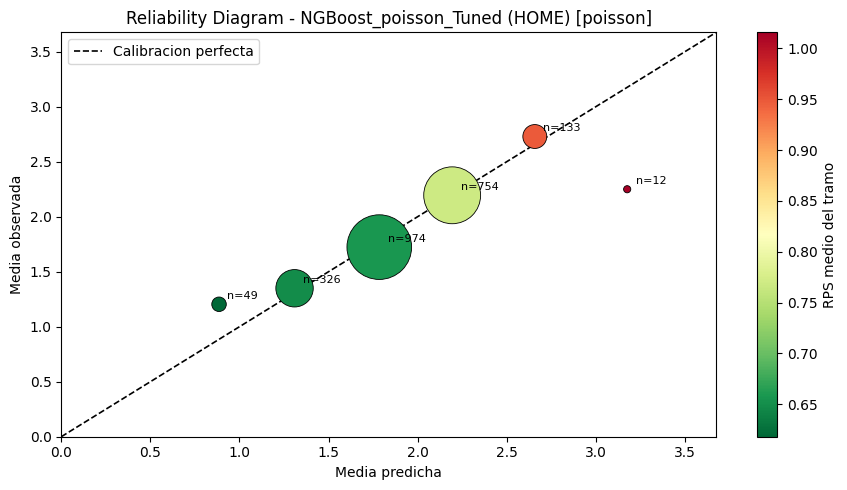


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_poisson_Tuned | HOME
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 348        -1.7078 -1.7506  -1.6609
     1 632        -0.8263 -0.8581  -0.7947
     2 611         0.0813  0.0529   0.1108
     3 381         1.0038  0.9673   1.0395
     4 192         1.9672  1.9085   2.0241
     5  53         2.9274  2.8201   3.0376
     6  25         3.6421  3.5019   3.7891
    7+   6         4.7788  4.4376   5.1813


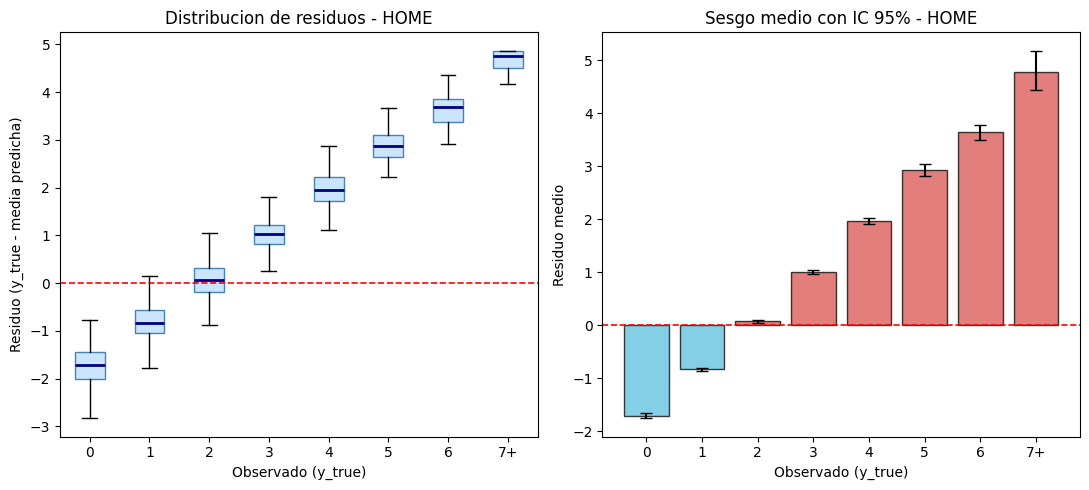


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_poisson_Tuned | HOME
------------------------------------------------------------
  Umbral RPS p95 : 1.76045
  En la cola          : 113 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  113    2.4052      4.7611     1.9842         2.7769
resto 2135    0.6218      1.7260     1.8879        -0.1619


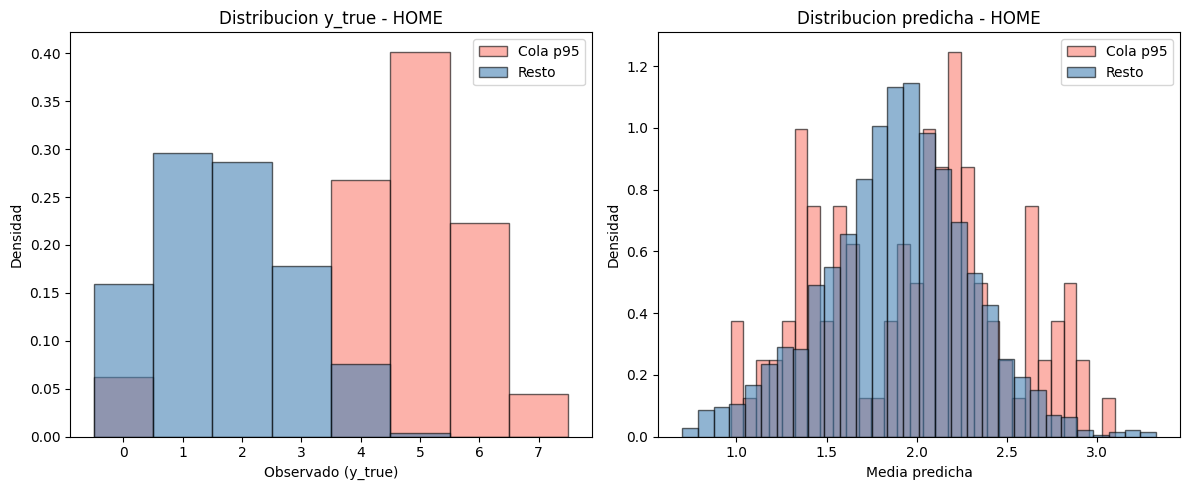


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_poisson_Tuned | HOME
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
            dfb_pokal  40  0.849755      -0.286203    1.825000   2.111203
               laliga 409  0.779793       0.033680    2.122249   2.088569
       premier-league 360  0.760356       0.112144    1.963889   1.851745
           bundesliga 293  0.725495       0.018032    1.849829   1.831797
uefa-champions-league 166  0.706631      -0.008492    1.771084   1.779577
      coupe_de_france  52  0.702976      -0.714465    0.961538   1.676003
   uefa-europa-league 169  0.702200       0.031035    2.017751   1.986717
              serie-a 395  0.664820      -0.055439    1.812658   1.868097
               fa-cup  22  0.643587      -0.224840    1.454545   1.679385
              ligue-1 310  0.593809      -0.007754    1.812903   1.820657


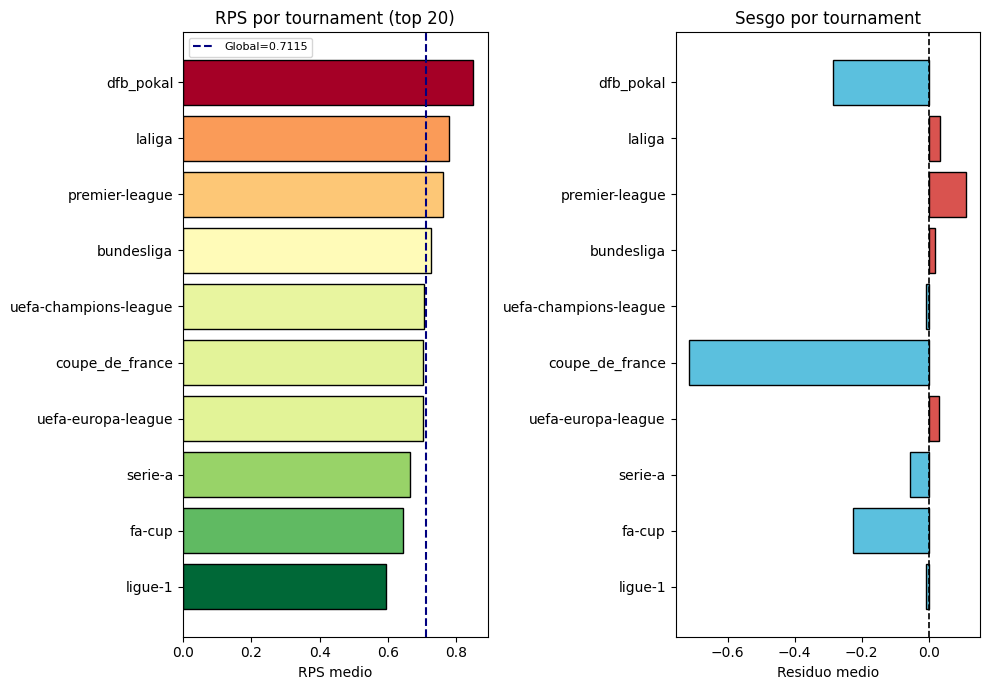


------------------------------------------------------------
  [5] Drift temporal - NGBoost_poisson_Tuned | HOME
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']


In [25]:
from src.error_analysis.distribution_error_analysis import DistributionErrorAnalyzer
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_home = df_cleaned.loc[X_val_home.index, META_VAL].reset_index(drop=True)

analyzer_home = DistributionErrorAnalyzer(
    params     = results["NGBoost"]["params"]["home"],   # ver nota abajo
    y_true     = y_val_home["home_total_cards"].values,
    family     = "poisson",
    meta       = meta_val_home,          # opcional: league, fecha, etc.
    component  = "home",
    model_name = "NGBoost_poisson_Tuned",
    config     = cfg,
)

analyzer_home.run_all()



  NGBoost_poisson_Tuned [poisson] - AWAY | N=2,248
  RPS mean=0.77192  |  media predicha=2.2012

------------------------------------------------------------
  [1] Calibracion - NGBoost_poisson_Tuned | AWAY
------------------------------------------------------------
  pred_bin    n  pred_mean  ytrue_mean  rps_mean
[1.0, 1.5)   69   1.359027    1.057971  0.651705
[1.5, 2.0)  591   1.817826    1.686971  0.691420
[2.0, 2.5) 1141   2.238607    2.202454  0.769397
[2.5, 3.0)  399   2.687808    2.694236  0.908744
[3.0, 3.5)   45   3.163598    2.977778  0.838737
[3.5, 4.0)    3   3.679101    5.333333  1.155164


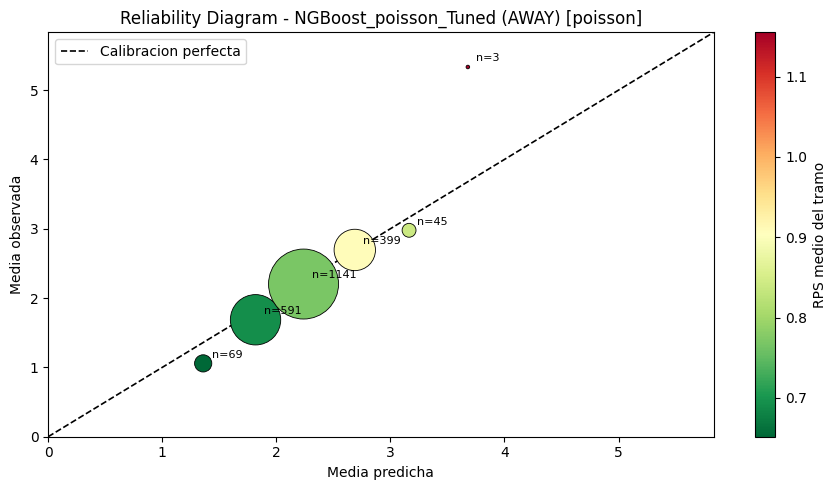


------------------------------------------------------------
  [2] Residuos por y_true - NGBoost_poisson_Tuned | AWAY
------------------------------------------------------------
y_true   n  residual_mean  ci_low  ci_high
     0 297        -2.0226 -2.0658  -1.9759
     1 515        -1.1069 -1.1389  -1.0763
     2 615        -0.2124 -0.2390  -0.1865
     3 449         0.7400  0.7067   0.7723
     4 221         1.6551  1.6026   1.7067
     5 102         2.6180  2.5481   2.6846
     6  30         3.4406  3.2771   3.5851
    7+  19         4.8897  4.6096   5.2113


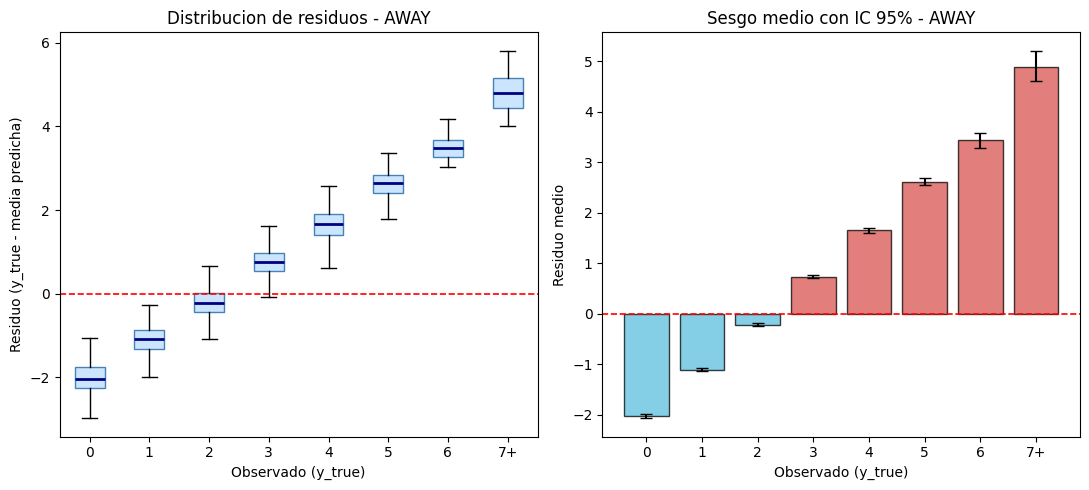


------------------------------------------------------------
  [3] Cola RPS > p95 - NGBoost_poisson_Tuned | AWAY
------------------------------------------------------------
  Umbral RPS p95 : 1.87026
  En la cola          : 113 (5.0%)

grupo    n  rps_mean  ytrue_mean  pred_mean  residual_mean
 cola  113    2.5828      5.1947     2.3289         2.8658
resto 2135    0.6761      1.9770     2.1944        -0.2173


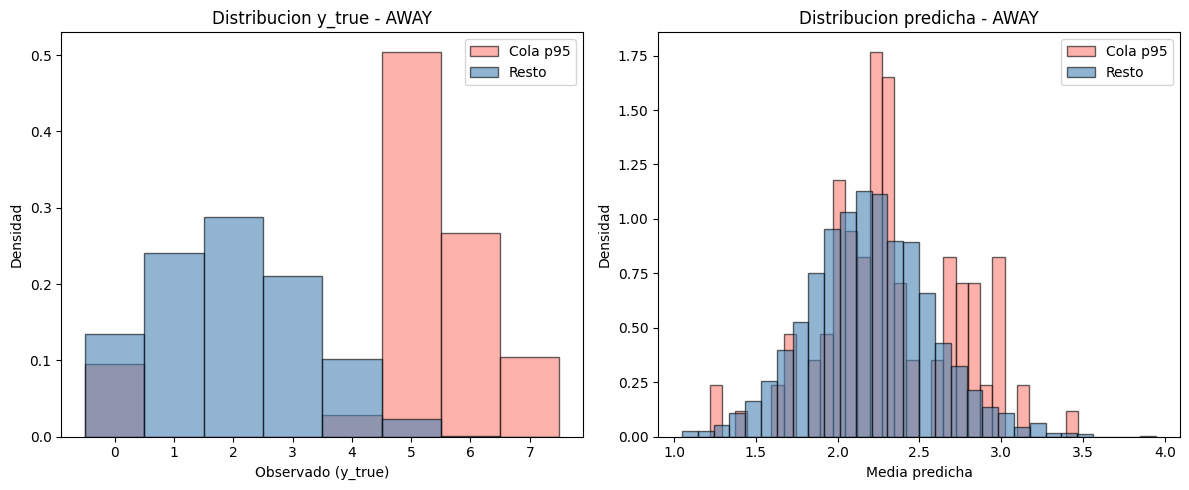


------------------------------------------------------------
  [4] Sesgo por 'tournament' - NGBoost_poisson_Tuned | AWAY
------------------------------------------------------------
           tournament   n  rps_mean  residual_mean  ytrue_mean  pred_mean
               fa-cup  22  0.965789      -0.162267    2.000000   2.162267
   uefa-europa-league 169  0.929695       0.208865    2.491124   2.282259
            dfb_pokal  40  0.887930       0.188152    2.475000   2.286848
      coupe_de_france  52  0.882868      -0.882994    1.192308   2.075302
               laliga 409  0.834286      -0.059064    2.347188   2.406252
       premier-league 360  0.797765       0.062866    2.219444   2.156578
uefa-champions-league 166  0.772373      -0.246179    1.873494   2.119673
           bundesliga 293  0.724273      -0.065567    2.030717   2.096284
              serie-a 395  0.689449      -0.021815    2.167089   2.188904
              ligue-1 310  0.666862      -0.111083    2.000000   2.111083


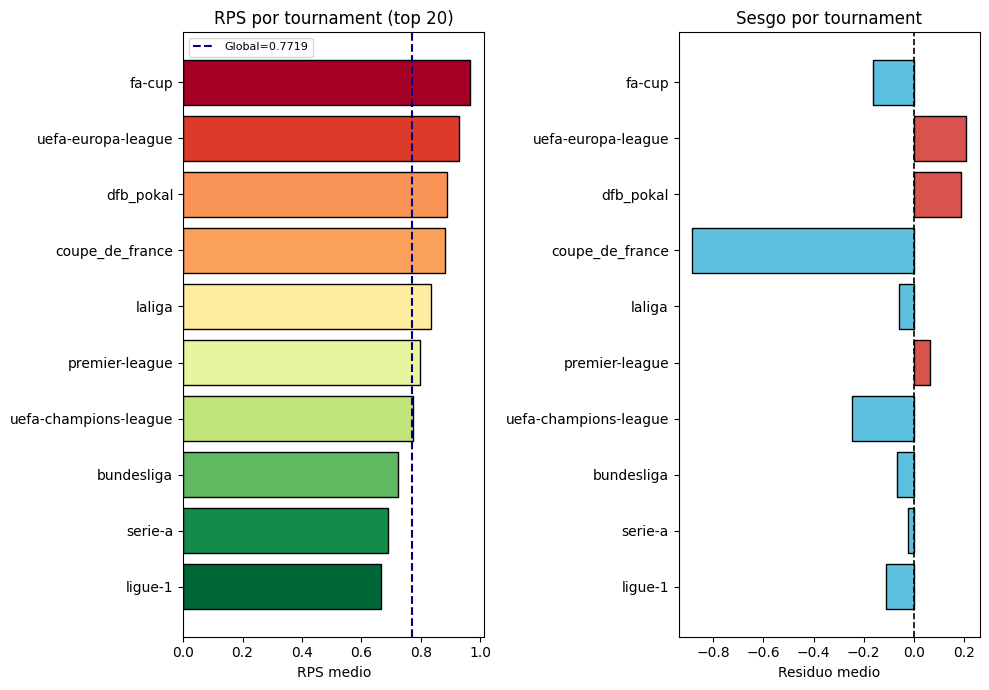


------------------------------------------------------------
  [5] Drift temporal - NGBoost_poisson_Tuned | AWAY
------------------------------------------------------------
  [SKIP] Ninguna columna temporal disponible: ['year_month', 'matchweek', 'date', 'match_date', 'season_week']


In [26]:
META_VAL = ['match_datetime_utc', 'tournament']
meta_val_away = df_cleaned.loc[X_val_away.index, META_VAL].reset_index(drop=True)
analyzer_away = DistributionErrorAnalyzer(
    params     = results["NGBoost"]["params"]["away"],   # ver nota abajo
    y_true     = y_val_away["away_total_cards"].values,
    family     = "poisson",
    meta       = meta_val_away,          
    component  = "away",
    model_name = "NGBoost_poisson_Tuned",
    config     = cfg,
)
analyzer_away.run_all()


------------------------------------------------------------
  [6] Correlacion de error HOME vs AWAY | NGBoost_poisson_Tuned
------------------------------------------------------------
  N observaciones    : 2,248
  Spearman rho (RPS) : 0.0931  p=9.7167e-06
  Spearman rho (res) : 0.1876  p=2.9364e-19
  Spearman rho (log) : 0.1929  p=2.7450e-20

  Interpretacion: Correlacion baja: los componentes fallan de forma independiente.


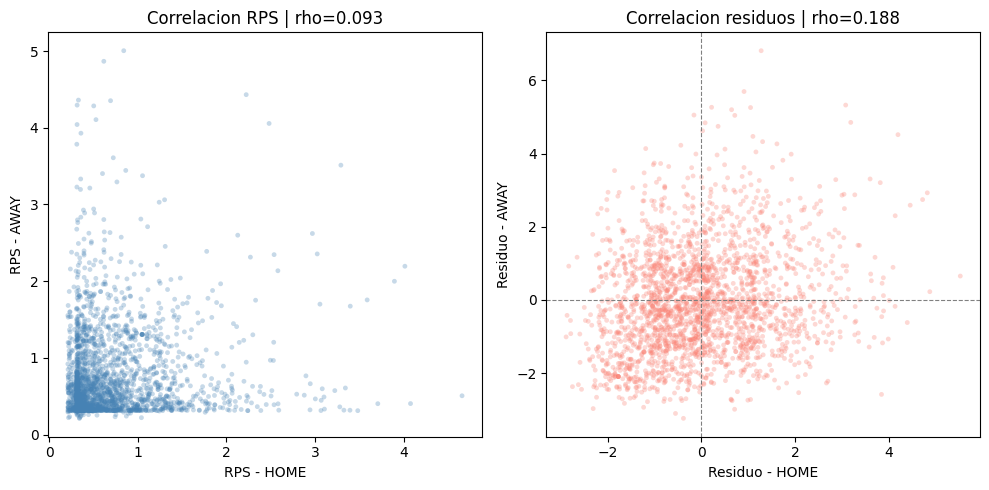

{'rho_rps': 0.0931435210331511,
 'p_rps': 9.716701726396872e-06,
 'rho_residual': 0.1876324741642903,
 'p_residual': 2.9363880811474625e-19,
 'rho_log': 0.19291618309406602,
 'p_log': 2.744985180060298e-20}

In [17]:
DistributionErrorAnalyzer.correlation_between(analyzer_home, analyzer_away)

### Test Evaluation

In [27]:
X_te = {"home": X_test_home, "away": X_test_away}
y_te = {"home": y_test_home["home_total_cards"], "away": y_test_away["away_total_cards"]}

summary_test, results_test = evaluate_on_validation(
    cfg, X_tr, y_tr, X_va, y_va, feats,   # val sigue siendo el early stopping
    models      = ["NGBoost"],
    family      = "poisson",
    best_params = best,
    X_eval      = X_te,                    # las metricas salen de aca
    y_eval      = y_te,
)

print(summary_test.to_string(index=False))

save_evaluation(results_test["NGBoost"], "test_ngboost_poisson_results", cfg,
                metadata={"split": "test", "label": "NGBoost_Poisson_Tuned"},
                metrics_dir=MODEL_DIR)

--- Entrenando NGBoost | home [poisson] ---
--- Entrenando NGBoost | away [poisson] ---

  FULL EVALUATION - NGBoost | poisson [poisson]

--------------------------------------------------
  RPS Report - NGBoost | poisson | home [poisson]
--------------------------------------------------
  N observaciones : 2527
  RPS mean        : 0.69970   <- principal
  RPS std         : 0.53516
  RPS median      : 0.50688
  RPS p95         : 1.65995   <- cola
--------------------------------------------------

--------------------------------------------------
  RPS Report - NGBoost | poisson | away [poisson]
--------------------------------------------------
  N observaciones : 2527
  RPS mean        : 0.74727   <- principal
  RPS std         : 0.54982
  RPS median      : 0.55859
  RPS p95         : 1.76443   <- cola
--------------------------------------------------

--------------------------------------------------
  NLL Report - NGBoost | poisson | home [poisson]
-----------------------------

WindowsPath('c:/Users/javie/OneDrive/Escritorio/ModelosProbabilisticos/EnvOficial/outputs/models/cards/test_ngboost_poisson_results.json')

# Result

In [28]:
import importlib
import numpy as np
import pandas as pd

# ── 0. Recargar los modulos editados (evita reiniciar el kernel) ─────
import src.evaluation.model_persistence as _mp
importlib.reload(_mp)

from src.config.config import load_config
from src.evaluation.persistence import load_best_params, save_evaluation
from src.metrics.distribution_metrics import evaluate_from_config
from src.training.distribution_models import (
    train_and_predict, predict_params, clip_params,
)

# Se toman del modulo recargado, no de un `from ... import` previo:
# ese binding seguiria apuntando a la funcion vieja sin category_map.
build_bundle = _mp.build_bundle
save_bundle  = _mp.save_bundle

cfg = load_config(CONFIG_PATH / "cards_config.yaml")
assert cfg.target.name == "cards", cfg.target.name

# ── 1. Cargar best params del YAML (el tuning ya corrio) ─────────────
best = {
    comp: load_best_params("NGBoost", cfg, family="poisson",
                            component=comp, params_only=True)
    for comp in ("home", "away")
}
for comp in ("home", "away"):
    assert best[comp], f"best params vacios para {comp}: se guardaria el modelo base"
    print(f"  [TUNED] {comp}: {best[comp]}")

# ── 2. Reentrenar con esos params ────────────────────────────────────
#     val = early stopping | test = metricas
cat_maps = {"home": cat_features_home, "away": cat_features_away}

trained = {}
for comp, X_tr, y_tr, X_va, y_va, feats in [
    ("home", X_train_home, y_train_home["home_total_cards"],
            X_val_home,   y_val_home["home_total_cards"],   X_train_home.columns.to_list()),
    ("away", X_train_away, y_train_away["away_total_cards"],
            X_val_away,   y_val_away["away_total_cards"],   X_train_away.columns.to_list()),
]:
    model, _, imputer = train_and_predict(
        "NGBoost", "poisson",
        X_tr[feats], y_tr, X_va[feats], y_va,
        params={**cfg.model_params("NGBoost"), **best[comp]},
        fit_params=cfg.fit_params("NGBoost"),
        guards=cfg.numeric_guards,
        return_imputer=True,
    )
    trained[comp] = {"model": model, "imputer": imputer, "features": feats}

# ── 3. Predecir sobre TEST y evaluar ─────────────────────────────────
params_test = {}
for comp, X_te in [("home", X_test_home), ("away", X_test_away)]:
    t = trained[comp]
    X_use = X_te[t["features"]]
    if t["imputer"] is not None:
        # El ColumnTransformer emite en orden num->cat, NO en el de entrada.
        # Hay que REINDEXAR por nombre; construir un DataFrame con
        # `columns=X_use.columns` reetiqueta y cruza las features.
        X_use = t["imputer"].transform(X_use)[t["features"]]
    raw = predict_params(t["model"], X_use, "NGBoost", "poisson")
    params_test[comp] = clip_params(raw, "poisson", cfg.numeric_guards)

results = evaluate_from_config(
    y_true={"home": y_test_home["home_total_cards"].values,
            "away": y_test_away["away_total_cards"].values},
    params=params_test,
    config=cfg, family="poisson", label="NGBoost_poisson_Tuned",
)
save_evaluation(results, "ngboost_poisson_test_results", config=cfg,
                metadata={"split": "test"})

# ── 4. Guardar los bundles ───────────────────────────────────────────
for comp in ("home", "away"):
    t, p = trained[comp], params_test[comp]
    bundle = build_bundle(
        model=t["model"], model_name="NGBoost", family="poisson",
        component=comp, features=t["features"], config=cfg,
        imputer=t["imputer"],
        best_params=best[comp],
        category_map=cat_maps[comp],
        metrics={
            "test_rps":     results["rps"][comp]["rps_mean"],
            "test_nll":     results["nll"][comp],
            "test_mu_mean": float(np.mean(p["lambda"])),
            "test_n":       int(results["rps"][comp]["n_samples"]),
        },
    )
    save_bundle(bundle, cfg)
    print(f"  [CHECK] {comp} category_map: "
        f"{ {k: len(v) for k, v in bundle['metadata']['category_map'].items()} }")

  [TUNED] home: {'max_depth': 2, 'min_samples_leaf': 49, 'n_estimators': 1950, 'learning_rate': 0.005003882139056356, 'col_sample': 0.7451044774412743}
  [TUNED] away: {'max_depth': 2, 'min_samples_leaf': 11, 'n_estimators': 1300, 'learning_rate': 0.005552618533578472, 'col_sample': 0.7260144888091878}
 [METRICS] ngboost_poisson_test_results -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\model_metrics\cards\ngboost_poisson_test_results.json
 [MODEL] ngboost_poisson_home_8 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\cards\ngboost_poisson_home_8.pkl  (0.8 MB)
  [CHECK] home category_map: {'tournament': 20}
 [MODEL] ngboost_poisson_away_9 -> C:\Users\javie\OneDrive\Escritorio\ModelosProbabilisticos\EnvOficial\outputs\clubs\models\cards\ngboost_poisson_away_9.pkl  (1.0 MB)
  [CHECK] away category_map: {'tournament': 20}
